In [2]:
#1. House Sales in King County, USA

#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [4]:
#Loading the dataset
df = pd.read_csv('kc_house_data.csv')

#preview first 5 rows
print(df.head())


           id             date     price  bedrooms  bathrooms  sqft_living  \
0  7129300520  20141013T000000  221900.0         3       1.00         1180   
1  6414100192  20141209T000000  538000.0         3       2.25         2570   
2  5631500400  20150225T000000  180000.0         2       1.00          770   
3  2487200875  20141209T000000  604000.0         4       3.00         1960   
4  1954400510  20150218T000000  510000.0         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0      5650     1.0           0     0  ...      7        1180              0   
1      7242     2.0           0     0  ...      7        2170            400   
2     10000     1.0           0     0  ...      6         770              0   
3      5000     1.0           0     0  ...      7        1050            910   
4      8080     1.0           0     0  ...      8        1680              0   

   yr_built  yr_renovated  zipcode      lat     lo

In [6]:
#summary of data types and non-null counts
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [10]:
#1. Data cleaning and handling missing values

#i. finding missing values
missing = df.isnull().sum()
#isnull() returns a True value if it contains a missing value 
#sum() adds up the boolean values. 

missing_pct = (df.isnull().sum() / len(df)) * 100 #missing data percentage, used for further actions

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
    
})

missing_df = missing_df[missing_df['Missing Count'] > 0] #Shows columns that have at least 1 missing value

if missing_df.empty: #returns True if The DataFrame has no rows or columns.
    print('No missing values found in the dataset.')
else:
    print('Columns with missing values:')
    print(missing_df)




No missing values found in the dataset.


In [12]:
#ii. checking for duplicate rows
#count duplicate rows
duplicates =df.duplicated().sum() 
#duplicated() evaluates every row and returns a boolean Series 

#if duplicates exist then simply remove them
if duplicates > 0:
    df = df.drop_duplicates() #de
    print(f'Duplicates removed. New shape: {df.shape}') 
    #.shape returns a tuple representing the dimensionality of the DataFrame in the format (rows, columns)

else:
    print('No duplicate rows found.')

No duplicate rows found.


In [24]:
#iii. Checking for incorrect or inconsistent values

#check for houses with 0 bedrooms or 0 bathrooms and remove them, because a house must have at least 1 bedroom
print('Houses with 0 bedrooms:', (df['bedrooms'] == 0).sum())
print('Houses with 0 bathrooms:', (df['bathrooms'] == 0).sum())

df = df[df['bedrooms'] > 0]
df = df[df['bathrooms'] > 0]

#also removes houses with unrealistic bedroom and bathroom count as an average county wouldn't have that many
#say 20 is the outlier
print('Houses with more than 20 bedrooms:', (df['bedrooms'] > 20).sum())
print('Houses with more than 20 bathrooms:', (df['bathrooms'] > 20).sum())


df = df[df['bedrooms'] < 20]
df = df[df['bathrooms'] < 20]

print(f'Dataset shape after cleaning: {df.shape}')

#convert the date column to a proper datetime format
df['date'] = pd.to_datetime(df['date'])

print('Date column converted successfully.')

#overall output after cleaning
print('Final dataset shape: ', df.shape)
print('\n Missing values after cleaning: ')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('Data cleaning complete.')


Houses with 0 bedrooms: 0
Houses with 0 bathrooms: 0
Houses with more than 20 bedrooms: 0
Houses with more than 20 bathrooms: 0
Dataset shape after cleaning: (21596, 21)
Date column converted successfully.
Final dataset shape:  (21596, 21)

 Missing values after cleaning: 
Series([], dtype: int64)
Data cleaning complete.


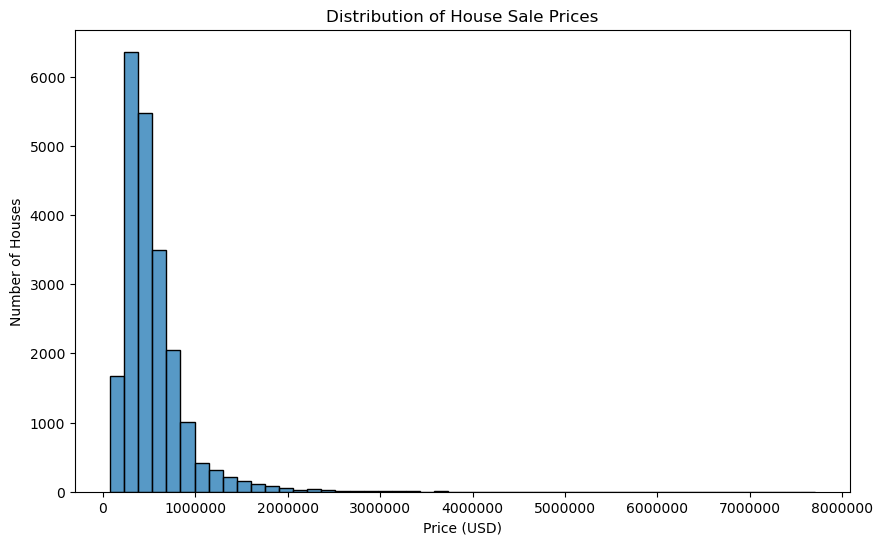

In [32]:
#2. Data Visualization
#i. Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50)

plt.title('Distribution of House Sale Prices')
plt.xlabel('Price (USD)')
plt.ylabel('Number of Houses')
plt.ticklabel_format(style='plain', axis='x')
plt.show()